# Named Entity Recognition System

## 0. Install & import dependencies

In [1]:
!pip install -q datasets


In [2]:
!pip install -q --upgrade pip setuptools wheel
!pip install -q seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
!pip install -q transformers accelerate evaluate


In [4]:
!pip install -q gensim


In [5]:
!pip install -q pytorch-crf


In [6]:
import os, time, json, random, zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, TimeDistributed, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from datasets import load_dataset
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

import torch
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                           TrainingArguments, Trainer, DataCollatorForTokenClassification)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())


TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Torch: 2.10.0+cu128 | CUDA: True


## 1. Load the CoNLL-2003 dataset

In [7]:
# Newer versions of `datasets` no longer execute dataset loading *scripts* (like conll2003.py)
# for security reasons. HuggingFace auto-converts script-based datasets to Parquet on a special
# branch (`refs/convert/parquet`), so we load directly from there to bypass the script entirely.
try:
    raw = load_dataset("eriktks/conll2003", revision="refs/convert/parquet")
except Exception as e:
    print("Primary source failed, falling back to tner/conll2003:", e)
    raw = load_dataset("tner/conll2003")

raw


conll2003/train/0000.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

In [8]:
label_list = raw["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}
print(label_list)


['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


### 1.1 Quick exploration

In [9]:
n_sent = {split: len(raw[split]) for split in raw}
print("Number of sentences per split:", n_sent)
print("Number of unique labels:", len(label_list))

all_tags = [t for split in raw for ex in raw[split]["ner_tags"] for t in ex]
tag_counts = pd.Series(all_tags).map(id2label).value_counts()
print("\nLabel distribution:\n", tag_counts)

sent_lens = [len(ex) for ex in raw["train"]["tokens"]]
print("\nAverage sentence length (train):", np.mean(sent_lens).round(2))
print("Max sentence length (train):", max(sent_lens))


Number of sentences per split: {'train': 14041, 'validation': 3250, 'test': 3453}
Number of unique labels: 9

Label distribution:
 O         250660
B-LOC      10645
B-PER      10059
B-ORG       9323
I-PER       6991
I-ORG       5290
B-MISC      5062
I-MISC      1717
I-LOC       1671
Name: count, dtype: int64

Average sentence length (train): 14.5
Max sentence length (train): 113


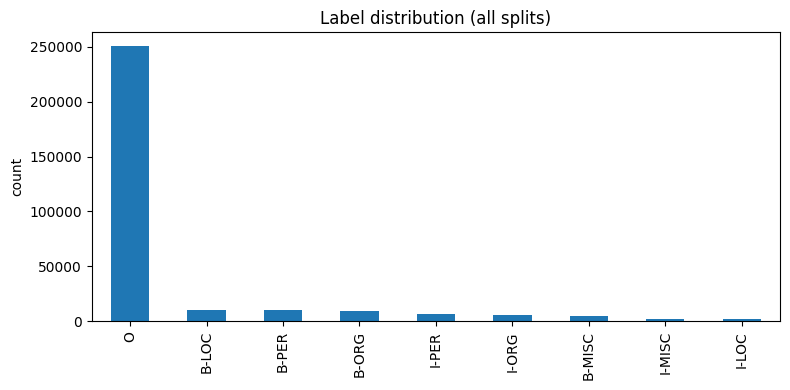

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
tag_counts.plot(kind="bar")
plt.title("Label distribution (all splits)")
plt.ylabel("count")
plt.tight_layout()
plt.show()


## 2. Preprocessing for the LSTM-family models

In [11]:
MAX_LEN = 128

def get_words_tags(split):
    return raw[split]["tokens"], raw[split]["ner_tags"]

train_words, train_tags = get_words_tags("train")
val_words, val_tags = get_words_tags("validation")
test_words, test_tags = get_words_tags("test")

# Vocabulary
word_counts = {}
for sent in train_words:
    for w in sent:
        word_counts[w.lower()] = word_counts.get(w.lower(), 0) + 1

vocab = ["<PAD>", "<UNK>"] + sorted(word_counts.keys())
word2idx = {w: i for i, w in enumerate(vocab)}
print("Vocab size:", len(vocab))

def encode_words(sentences):
    return [[word2idx.get(w.lower(), word2idx["<UNK>"]) for w in s] for s in sentences]

def encode_labels(tag_seqs):
    return [[t for t in seq] for seq in tag_seqs]  # already ints matching label2id

X_train = pad_sequences(encode_words(train_words), maxlen=MAX_LEN, padding="post", value=word2idx["<PAD>"])
X_val   = pad_sequences(encode_words(val_words),   maxlen=MAX_LEN, padding="post", value=word2idx["<PAD>"])
X_test  = pad_sequences(encode_words(test_words),  maxlen=MAX_LEN, padding="post", value=word2idx["<PAD>"])

y_train = pad_sequences(encode_labels(train_tags), maxlen=MAX_LEN, padding="post", value=label2id["O"])
y_val   = pad_sequences(encode_labels(val_tags),   maxlen=MAX_LEN, padding="post", value=label2id["O"])
y_test  = pad_sequences(encode_labels(test_tags),  maxlen=MAX_LEN, padding="post", value=label2id["O"])

y_train_cat = to_categorical(y_train, num_classes=len(label_list))
y_val_cat   = to_categorical(y_val,   num_classes=len(label_list))
y_test_cat  = to_categorical(y_test,  num_classes=len(label_list))

print(X_train.shape, y_train_cat.shape)


Vocab size: 21011
(14041, 128) (14041, 128, 9)


In [12]:
train_mask = (X_train != word2idx["<PAD>"]).astype(int)
val_mask   = (X_val   != word2idx["<PAD>"]).astype(int)
test_mask  = (X_test  != word2idx["<PAD>"]).astype(int)


### 2.1 Pretrained word embeddings (GloVe)

In [13]:
import gensim.downloader as api
print("Downloading GloVe (100d)... this can take a minute on first run.")
glove = api.load("glove-wiki-gigaword-100")
EMB_DIM = 100

embedding_matrix = np.zeros((len(vocab), EMB_DIM))
hits = 0
for word, idx in word2idx.items():
    if word in glove:
        embedding_matrix[idx] = glove[word]
        hits += 1
print(f"Found embeddings for {hits}/{len(vocab)} words ({hits/len(vocab)*100:.1f}%)")


[==================================================] 100.0% 128.1/128.1MB downloaded
Found embeddings for 18415/21011 words (87.6%)


## 3. Build & train the four models

Helper: convert padded predictions back to `seqeval`-compatible label sequences (stripping padding)
so precision/recall/F1 are computed only on real tokens.

In [14]:
def preds_to_seqeval(y_true_ids, y_pred_ids, mask):
    true_labels, pred_labels = [], []
    for t_seq, p_seq, m_seq in zip(y_true_ids, y_pred_ids, mask):
        t_sent, p_sent = [], []
        for t, p, m in zip(t_seq, p_seq, m_seq):
            if m == 0:
                continue
            t_sent.append(id2label[t])
            p_sent.append(id2label[p])
        true_labels.append(t_sent)
        pred_labels.append(p_sent)
    return true_labels, pred_labels

def evaluate_keras_model(model, X, y_ids, mask, name):
    t0 = time.time()
    probs = model.predict(X, verbose=0)
    infer_time = time.time() - t0
    pred_ids = np.argmax(probs, axis=-1)
    y_true, y_pred = preds_to_seqeval(y_ids, pred_ids, mask)
    report = classification_report(y_true, y_pred, digits=4)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(report)
    return {"model": name, "precision": prec, "recall": rec, "f1": f1,
            "inference_sec_per_1000": infer_time / len(X) * 1000}


### 3.1 Model 1 — LSTM

In [15]:
def build_lstm(bidirectional=False, use_crf=False):
    inp = Input(shape=(MAX_LEN,))
    emb = Embedding(input_dim=len(vocab), output_dim=EMB_DIM,
                     weights=[embedding_matrix], input_length=MAX_LEN,
                     mask_zero=True, trainable=True)(inp)
    if bidirectional:
        x = Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.1))(emb)
    else:
        x = LSTM(128, return_sequences=True, recurrent_dropout=0.1)(emb)
    x = TimeDistributed(Dense(64, activation="relu"))(x)
    out = TimeDistributed(Dense(len(label_list), activation="softmax"))(x)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

lstm_model = build_lstm(bidirectional=False)
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784747874.466970      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784747874.469929      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 100)  │  2,101,100 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128, 128)  │    117,248 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 128, 64)   │      8,256 │ lstm[0][0],       │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 128, 9)    │        585 │ time_distributed… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,227,189 (8.50 MB)

 Trainable params: 2,227,189 (8.50 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
t0 = time.time()
history_lstm = lstm_model.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                               batch_size=64, epochs=5, verbose=1)
lstm_train_time = time.time() - t0
print("LSTM training time (s):", lstm_train_time)


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 108s 422ms/step - accuracy: 0.8881 - loss: 0.4385 - val_accuracy: 0.9348 - val_loss: 0.2418
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 90s 411ms/step - accuracy: 0.9574 - loss: 0.1482 - val_accuracy: 0.9459 - val_loss: 0.1819
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 91s 414ms/step - accuracy: 0.9708 - loss: 0.0987 - val_accuracy: 0.9502 - val_loss: 0.1690
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 91s 412ms/step - accuracy: 0.9778 - loss: 0.0742 - val_accuracy: 0.9506 - val_loss: 0.1744
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 92s 416ms/step - accuracy: 0.9819 - loss: 0.0584 - val_accuracy: 0.9516 - val_loss: 0.1806
LSTM training time (s): 471.63565707206726


In [17]:
lstm_val_acc = history_lstm.history["val_accuracy"][-1]
lstm_results = evaluate_keras_model(lstm_model, X_test, y_test, test_mask, "LSTM")
lstm_results.update({"training_time_sec": lstm_train_time, "val_accuracy": lstm_val_acc})
lstm_results


--- LSTM ---
              precision    recall  f1-score   support

         LOC     0.7798    0.7920    0.7858      1668
        MISC     0.6188    0.5826    0.6001       702
         ORG     0.6719    0.5376    0.5973      1661
         PER     0.8133    0.5226    0.6363      1617

   micro avg     0.7343    0.6140    0.6688      5648
   macro avg     0.7209    0.6087    0.6549      5648
weighted avg     0.7377    0.6140    0.6645      5648



{'model': 'LSTM',
 'precision': np.float64(0.7342790599195427),
 'recall': np.float64(0.6140226628895185),
 'f1': np.float64(0.6687879664448944),
 'inference_sec_per_1000': 3.9841812519346362,
 'training_time_sec': 471.63565707206726,
 'val_accuracy': 0.9515789747238159}

### 3.2 Model 2 — BiLSTM

In [18]:
bilstm_model = build_lstm(bidirectional=True)
t0 = time.time()
history_bilstm = bilstm_model.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                                   batch_size=64, epochs=5, verbose=1)
bilstm_train_time = time.time() - t0
print("BiLSTM training time (s):", bilstm_train_time)


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 182s 762ms/step - accuracy: 0.8983 - loss: 0.3839 - val_accuracy: 0.9445 - val_loss: 0.1972
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 165s 751ms/step - accuracy: 0.9651 - loss: 0.1207 - val_accuracy: 0.9574 - val_loss: 0.1425
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 166s 753ms/step - accuracy: 0.9787 - loss: 0.0736 - val_accuracy: 0.9600 - val_loss: 0.1357
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 167s 760ms/step - accuracy: 0.9857 - loss: 0.0495 - val_accuracy: 0.9589 - val_loss: 0.1532
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 166s 752ms/step - accuracy: 0.9900 - loss: 0.0348 - val_accuracy: 0.9615 - val_loss: 0.1439
BiLSTM training time (s): 845.862556219101


In [19]:
bilstm_val_acc = history_bilstm.history["val_accuracy"][-1]
bilstm_results = evaluate_keras_model(bilstm_model, X_test, y_test, test_mask, "BiLSTM")
bilstm_results.update({"training_time_sec": bilstm_train_time, "val_accuracy": bilstm_val_acc})
bilstm_results


--- BiLSTM ---
              precision    recall  f1-score   support

         LOC     0.8354    0.8034    0.8191      1668
        MISC     0.7061    0.6709    0.6881       702
         ORG     0.7265    0.6526    0.6876      1661
         PER     0.7723    0.5937    0.6713      1617

   micro avg     0.7701    0.6825    0.7237      5648
   macro avg     0.7601    0.6802    0.7165      5648
weighted avg     0.7693    0.6825    0.7218      5648



{'model': 'BiLSTM',
 'precision': np.float64(0.7700759089093089),
 'recall': np.float64(0.6825424929178471),
 'f1': np.float64(0.7236718603341468),
 'inference_sec_per_1000': 5.476714009103518,
 'training_time_sec': 845.862556219101,
 'val_accuracy': 0.9614500999450684}

### 3.3 Model 3 — BiLSTM + CRF

In [20]:
import torch.nn as nn
from torchcrf import CRF as TorchCRF
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class NERTensorDataset(Dataset):
    def __init__(self, X, y, mask):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        self.mask = torch.tensor(mask, dtype=torch.bool)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.mask[i]

train_loader = DataLoader(NERTensorDataset(X_train, y_train, train_mask), batch_size=64, shuffle=True)
val_loader   = DataLoader(NERTensorDataset(X_val, y_val, val_mask), batch_size=64)
test_loader  = DataLoader(NERTensorDataset(X_test, y_test, test_mask), batch_size=64)

class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_labels, embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.lstm = nn.LSTM(emb_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)
        self.crf = TorchCRF(num_labels, batch_first=True)

    def forward(self, x, mask):
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        emissions = self.fc(lstm_out)
        return emissions

    def loss(self, x, y, mask):
        emissions = self.forward(x, mask)
        # CRF requires the first timestep of every sequence to be valid
        mask = mask.clone()
        mask[:, 0] = True
        return -self.crf(emissions, y, mask=mask, reduction="mean")

    def predict(self, x, mask):
        emissions = self.forward(x, mask)
        mask = mask.clone()
        mask[:, 0] = True
        return self.crf.decode(emissions, mask=mask)

crf_model = BiLSTM_CRF(len(vocab), EMB_DIM, 128, len(label_list), embedding_matrix).to(device)
optimizer = torch.optim.Adam(crf_model.parameters(), lr=1e-3)


Using device: cuda


In [21]:
EPOCHS = 5
t0 = time.time()
for epoch in range(EPOCHS):
    crf_model.train()
    total_loss = 0
    for xb, yb, mb in train_loader:
        xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
        optimizer.zero_grad()
        loss = crf_model.loss(xb, yb, mb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    crf_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb, mb in val_loader:
            xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
            val_loss += crf_model.loss(xb, yb, mb).item()

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {total_loss/len(train_loader):.4f} "
          f"- val_loss: {val_loss/len(val_loader):.4f}")

crf_train_time = time.time() - t0
print("BiLSTM+CRF training time (s):", crf_train_time)


Epoch 1/5 - train_loss: 6.4729 - val_loss: 3.2701
Epoch 2/5 - train_loss: 1.8451 - val_loss: 2.3276
Epoch 3/5 - train_loss: 1.0830 - val_loss: 2.0989
Epoch 4/5 - train_loss: 0.7110 - val_loss: 1.8465
Epoch 5/5 - train_loss: 0.4857 - val_loss: 1.9347
BiLSTM+CRF training time (s): 148.27641081809998


In [22]:
def evaluate_torch_crf(model, loader, name):
    model.eval()
    all_true, all_pred = [], []
    t0 = time.time()
    n_examples = 0
    with torch.no_grad():
        for xb, yb, mb in loader:
            xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
            pred_seqs = model.predict(xb, mb)  # list of variable-length label-id lists
            mb_np = mb.cpu().numpy()
            yb_np = yb.cpu().numpy()
            for i, pred_seq in enumerate(pred_seqs):
                length = int(mb_np[i].sum())
                true_seq = yb_np[i][:length]
                pred_seq = pred_seq[:length]
                all_true.append([id2label[t] for t in true_seq])
                all_pred.append([id2label[p] for p in pred_seq])
            n_examples += len(xb)
    infer_time = time.time() - t0
    report = classification_report(all_true, all_pred, digits=4)
    f1 = f1_score(all_true, all_pred)
    prec = precision_score(all_true, all_pred)
    rec = recall_score(all_true, all_pred)
    print(f"--- {name} ---")
    print(report)
    return {"model": name, "precision": prec, "recall": rec, "f1": f1,
            "inference_sec_per_1000": infer_time / n_examples * 1000}

crf_results = evaluate_torch_crf(crf_model, test_loader, "BiLSTM+CRF")
crf_val_acc = None  # CRF reports loss rather than token accuracy; F1 above is the key comparison metric
crf_results.update({"training_time_sec": crf_train_time, "val_accuracy": crf_val_acc})
crf_results


--- BiLSTM+CRF ---
              precision    recall  f1-score   support

         LOC     0.8783    0.8177    0.8469      1668
        MISC     0.7596    0.6752    0.7149       702
         ORG     0.7688    0.6845    0.7242      1661
         PER     0.8254    0.6840    0.7481      1617

   micro avg     0.8169    0.7226    0.7668      5648
   macro avg     0.8080    0.7154    0.7585      5648
weighted avg     0.8162    0.7226    0.7661      5648



{'model': 'BiLSTM+CRF',
 'precision': np.float64(0.8168534827862289),
 'recall': np.float64(0.722556657223796),
 'f1': np.float64(0.7668169860954528),
 'inference_sec_per_1000': 0.4820489482951447,
 'training_time_sec': 148.27641081809998,
 'val_accuracy': None}

### 3.4 Model 4 — Fine-tuned Transformer (DistilBERT, HuggingFace)

In [23]:
MODEL_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True, max_length=MAX_LEN)
    all_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)  # only label the first subword token of a word
            prev_word_id = word_id
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized

tokenized_ds = raw.map(tokenize_and_align_labels, batched=True, remove_columns=raw["train"].column_names)
tokenized_ds


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})

In [24]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

transformer_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=len(label_list), id2label=id2label, label2id=label2id
)

import evaluate as hf_evaluate
seqeval_metric = hf_evaluate.load("seqeval")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    true_labels, true_preds = [], []
    for pred_seq, label_seq in zip(preds, labels):
        tp, tl = [], []
        for p, l in zip(pred_seq, label_seq):
            if l == -100:
                continue
            tp.append(id2label[p]); tl.append(id2label[l])
        true_preds.append(tp); true_labels.append(tl)
    results = seqeval_metric.compute(predictions=true_preds, references=true_labels)
    return {"precision": results["overall_precision"], "recall": results["overall_recall"],
            "f1": results["overall_f1"], "accuracy": results["overall_accuracy"]}

training_args = TrainingArguments(
    output_dir="/kaggle/working/distilbert-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer.train()
transformer_train_time = time.time() - t0
print("Transformer training time (s):", transformer_train_time)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.125901,0.884710,0.907055,0.895743,0.981380
2,0.361145,0.101798,0.913151,0.932985,0.922962,0.985646
3,0.088366,0.101947,0.919371,0.935006,0.927122,0.986405


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Transformer training time (s): 197.99152970314026


In [25]:
val_metrics = trainer.evaluate(tokenized_ds["validation"])
print("Validation metrics:", val_metrics)

t0 = time.time()
test_metrics = trainer.evaluate(tokenized_ds["test"])
transformer_infer_time = time.time() - t0
print("Test metrics:", test_metrics)

transformer_results = {
    "model": "Fine-tuned DistilBERT",
    "precision": test_metrics["eval_precision"],
    "recall": test_metrics["eval_recall"],
    "f1": test_metrics["eval_f1"],
    "training_time_sec": transformer_train_time,
    "val_accuracy": val_metrics["eval_accuracy"],
    "inference_sec_per_1000": transformer_infer_time / len(tokenized_ds["test"]) * 1000,
}
transformer_results


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Validation metrics: {'eval_loss': 0.1019466444849968, 'eval_precision': 0.9193708609271524, 'eval_recall': 0.9350058932480215, 'eval_f1': 0.927122464312547, 'eval_accuracy': 0.9864051574703465, 'eval_runtime': 4.7578, 'eval_samples_per_second': 683.091, 'eval_steps_per_second': 10.719, 'epoch': 3.0}
Test metrics: {'eval_loss': 0.20238088071346283, 'eval_precision': 0.8783151326053042, 'eval_recall': 0.8974495217853348, 'eval_f1': 0.8877792378449408, 'eval_accuracy': 0.9779213785675821, 'eval_runtime': 4.5716, 'eval_samples_per_second': 755.316, 'eval_steps_per_second': 11.812, 'epoch': 3.0}


{'model': 'Fine-tuned DistilBERT',
 'precision': 0.8783151326053042,
 'recall': 0.8974495217853348,
 'f1': 0.8877792378449408,
 'training_time_sec': 197.99152970314026,
 'val_accuracy': 0.9864051574703465,
 'inference_sec_per_1000': 1.3248682919703045}

## 4. Compare all four architectures

In [26]:
comparison = pd.DataFrame([lstm_results, bilstm_results, crf_results, transformer_results])
comparison = comparison[["model", "precision", "recall", "f1", "training_time_sec",
                          "val_accuracy", "inference_sec_per_1000"]]
comparison.sort_values("f1", ascending=False, inplace=True)
comparison


,model,precision,recall,f1,training_time_sec,val_accuracy,inference_sec_per_1000
3,Fine-tuned DistilBERT,0.878315,0.897450,0.887779,197.991530,0.986405,1.324868
2,BiLSTM+CRF,0.816853,0.722557,0.766817,148.276411,NaN,0.482049
1,BiLSTM,0.770076,0.682542,0.723672,845.862556,0.961450,5.476714
0,LSTM,0.734279,0.614023,0.668788,471.635657,0.951579,3.984181


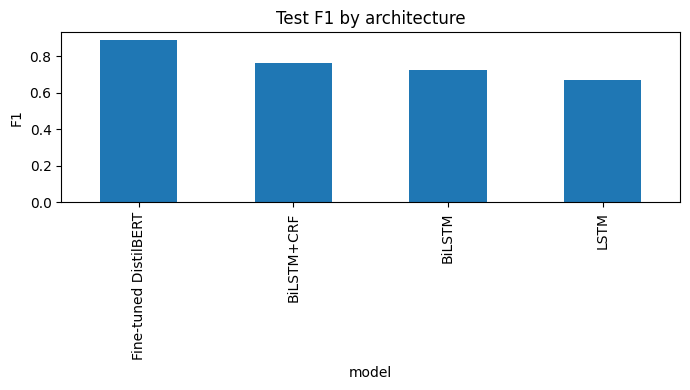


Notes:
- BiLSTM generally beats plain LSTM because it sees both left and right context.
- BiLSTM+CRF usually improves boundary consistency (fewer illegal transitions like O -> I-PER),
  which typically raises entity-level F1 over plain BiLSTM even when token accuracy is similar.
- The fine-tuned Transformer (DistilBERT) typically achieves the best F1 thanks to contextual
  subword embeddings pretrained on huge corpora, at the cost of longer training time.



In [27]:
ax = comparison.set_index("model")["f1"].plot(kind="bar", figsize=(7,4), title="Test F1 by architecture")
ax.set_ylabel("F1")
plt.tight_layout()
plt.show()

print("""
Notes:
- BiLSTM generally beats plain LSTM because it sees both left and right context.
- BiLSTM+CRF usually improves boundary consistency (fewer illegal transitions like O -> I-PER),
  which typically raises entity-level F1 over plain BiLSTM even when token accuracy is similar.
- The fine-tuned Transformer (DistilBERT) typically achieves the best F1 thanks to contextual
  subword embeddings pretrained on huge corpora, at the cost of longer training time.
""")


## 5. Visualize predictions on custom sentences

In [28]:
def predict_with_transformer(sentence, model=None, tok=None):
    model = model or trainer.model
    tok = tok or tokenizer
    model.eval()
    device = next(model.parameters()).device
    tokens = sentence.split()
    enc = tok(tokens, is_split_into_words=True, return_tensors="pt", truncation=True)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
    pred_ids = torch.argmax(logits, dim=-1)[0].tolist()
    word_ids = tok(tokens, is_split_into_words=True, truncation=True).word_ids()

    results = []
    prev_word = None
    for idx, wid in zip(pred_ids, word_ids):
        if wid is None or wid == prev_word:
            continue
        results.append((tokens[wid], id2label[idx]))
        prev_word = wid
    return results

for sent in ["Apple hired John in New York.", "Barack Obama visited Berlin last July."]:
    print(sent)
    for word, label in predict_with_transformer(sent):
        print(f"  {word:15s} -> {label}")
    print()


Apple hired John in New York.
  Apple           -> B-ORG
  hired           -> O
  John            -> B-PER
  in              -> O
  New             -> B-LOC
  York.           -> I-LOC

Barack Obama visited Berlin last July.
  Barack          -> B-PER
  Obama           -> I-PER
  visited         -> O
  Berlin          -> B-LOC
  last            -> O
  July.           -> O



## 6. Save the best model for deployment

In [29]:
SAVE_DIR = "/kaggle/working/ner_deployment_model"
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(os.path.join(SAVE_DIR, "label_maps.json"), "w") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f, indent=2)

with open(os.path.join(SAVE_DIR, "comparison.json"), "w") as f:
    json.dump(comparison.to_dict(orient="records"), f, indent=2)

zip_path = "/kaggle/working/ner_deployment_model.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(SAVE_DIR):
        for file in files:
            fp = os.path.join(root, file)
            zf.write(fp, os.path.relpath(fp, SAVE_DIR))

print("Saved to:", SAVE_DIR)
print("Zipped to:", zip_path)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /kaggle/working/ner_deployment_model
Zipped to: /kaggle/working/ner_deployment_model.zip
